In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (Input, Embedding, SpatialDropout1D, Conv1D, 
                                     GlobalMaxPooling1D, Dense, Dropout, 
                                     BatchNormalization, concatenate)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_recall_fscore_support, 
                             roc_curve, auc)
import gensim.downloader as api

# Downloads
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\heman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\MH_Sentiment_Project\Combined Data.csv")
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df.dropna(inplace=True)

# Resampling to Balance all 7 Classes
def resample_data(df):
    max_count = df['status'].value_counts().max()
    df_resampled = pd.DataFrame()
    for status in df['status'].unique():
        df_class = df[df['status'] == status]
        df_class_resampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
        df_resampled = pd.concat([df_resampled, df_class_resampled])
    return df_resampled

df = resample_data(df)
print("Balanced Classes:\n", df['status'].value_counts())

Balanced Classes:
 status
Anxiety                 16343
Normal                  16343
Depression              16343
Suicidal                16343
Stress                  16343
Bipolar                 16343
Personality disorder    16343
Name: count, dtype: int64


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text).lower())
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['statement'] = df['statement'].apply(preprocess_text)

# Label Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['status'].values)
y_categorical = to_categorical(y_encoded)

# Split (90-10)
X_train, X_test, y_train, y_test = train_test_split(df['statement'].values, y_categorical, test_size=0.1, random_state=42)

# Tokenization
max_words = 50000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')

In [4]:
print("Loading Word2Vec model...")
word2vec_model = api.load("word2vec-google-news-300")
embedding_dim = 300
num_words = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words:
        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
print("Embedding Matrix ready.")

Loading Word2Vec model...
Embedding Matrix ready.


In [5]:
def build_cnn():
    input_layer = Input(shape=(max_len,))
    
    # Embedding
    x = Embedding(num_words, embedding_dim, weights=[embedding_matrix], 
                  input_length=max_len, trainable=False)(input_layer)
    x = SpatialDropout1D(0.3)(x)
    
    # Parallel Convolutional layers with different kernel sizes (3, 4, 5)
    # This allows the model to detect 3-word, 4-word, and 5-word phrases
    branch1 = Conv1D(128, 3, padding='same', activation='relu')(x)
    branch1 = GlobalMaxPooling1D()(branch1)
    
    branch2 = Conv1D(128, 4, padding='same', activation='relu')(x)
    branch2 = GlobalMaxPooling1D()(branch2)
    
    branch3 = Conv1D(128, 5, padding='same', activation='relu')(x)
    branch3 = GlobalMaxPooling1D()(branch3)
    
    # Concatenate parallel branches
    merged = concatenate([branch1, branch2, branch3])
    
    # Fully Connected Dense Layers
    x = Dense(256, activation='relu')(merged)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(7, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output, name="CNN_Mental_Health_Model")
    return model

model = build_cnn()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()



Model: "CNN_Mental_Health_Model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 100, 300)             1500000   ['input_1[0][0]']             
                                                          0                                       
                                                                                                  
 spatial_dropout1d (Spatial  (None, 100, 300)             0         ['embedding[0][0]']           
 Dropout1D)                                                                                       
                                                                          

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=12,
    batch_size=64,
    callbacks=callbacks
)

# Saving as requested
model.save("sentiment analysis cnn.keras")
model.save("mental_health_model cnn.h5")
print("CNN Model saved successfully.")

Epoch 1/12


1609/1609 [==============================] - 80s 48ms/step - loss: 0.8857 - accuracy: 0.6794 - val_loss: 0.5369 - val_accuracy: 0.8019 - lr: 0.0010
Epoch 2/12
1609/1609 [==============================] - 73s 45ms/step - loss: 0.5031 - accuracy: 0.8191 - val_loss: 0.3845 - val_accuracy: 0.8539 - lr: 0.0010
Epoch 3/12
1609/1609 [==============================] - 70s 43ms/step - loss: 0.3968 - accuracy: 0.8556 - val_loss: 0.2803 - val_accuracy: 0.8886 - lr: 0.0010
Epoch 4/12
1609/1609 [==============================] - 77s 48ms/step - loss: 0.3456 - accuracy: 0.8741 - val_loss: 0.2914 - val_accuracy: 0.8860 - lr: 0.0010
Epoch 5/12
1609/1609 [==============================] - 76s 47ms/step - loss: 0.3079 - accuracy: 0.8882 - val_loss: 0.2088 - val_accuracy: 0.9232 - lr: 0.0010
Epoch 6/12
1609/1609 [==============================] - 75s 46ms/step - loss: 0.2793 - accuracy: 0.9006 - val_loss: 0.2064 - val_accuracy: 0.9282 - lr: 0.0010
Epoch 7/12
1609/1609 [======================

c:\MH_Sentiment_Project\mh_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [7]:
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics Calculation
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
performance_df = pd.DataFrame({
    'Emotion': label_encoder.classes_,
    'Precision': precision, 'Recall': recall, 'F1-Score': f1
})

print("\n--- CNN PERFORMANCE TABLE ---")
print(performance_df)
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

358/358 [==============================] - 3s 9ms/step

--- CNN PERFORMANCE TABLE ---
                Emotion  Precision    Recall  F1-Score
0               Anxiety   0.990583  0.995858  0.993213
1               Bipolar   0.991049  1.000000  0.995504
2            Depression   0.883553  0.857809  0.870491
3                Normal   0.954244  0.970606  0.962356
4  Personality disorder   0.996845  1.000000  0.998420
5                Stress   0.979218  0.995031  0.987061
6              Suicidal   0.889571  0.872443  0.880923

--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

             Anxiety       0.99      1.00      0.99      1690
             Bipolar       0.99      1.00      1.00      1550
          Depression       0.88      0.86      0.87      1716
              Normal       0.95      0.97      0.96      1633
Personality disorder       1.00      1.00      1.00      1580
              Stress       0.98      1.00      0.99      1610
        

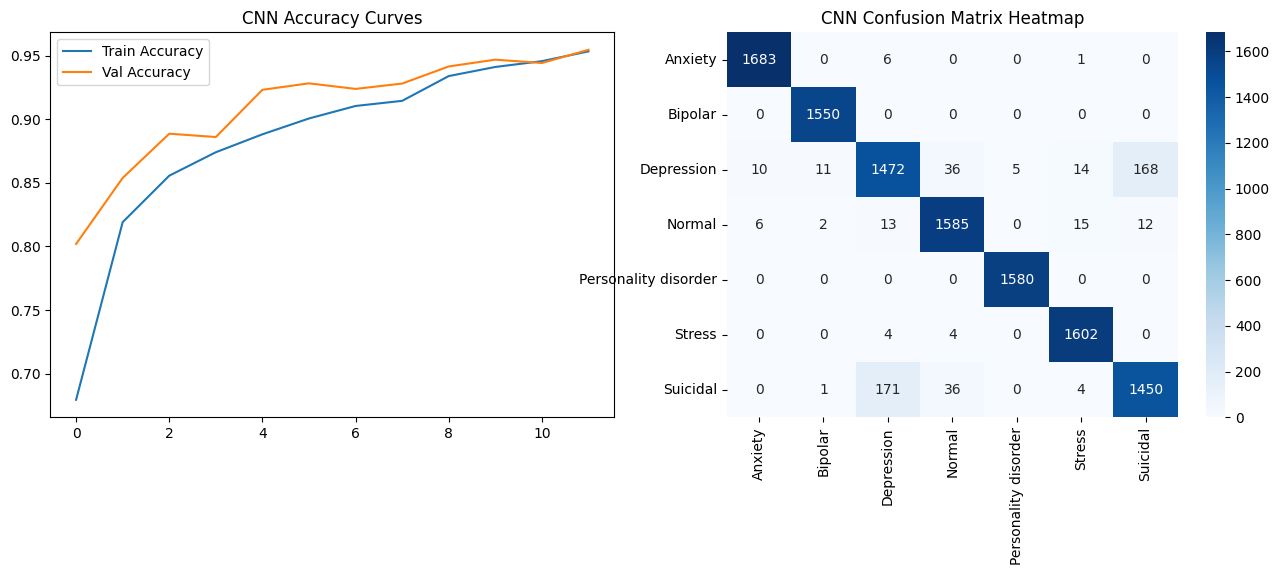

In [8]:
plt.figure(figsize=(16, 5))

# Plot Accuracy & Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy Curves')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('CNN Confusion Matrix Heatmap')
plt.show()

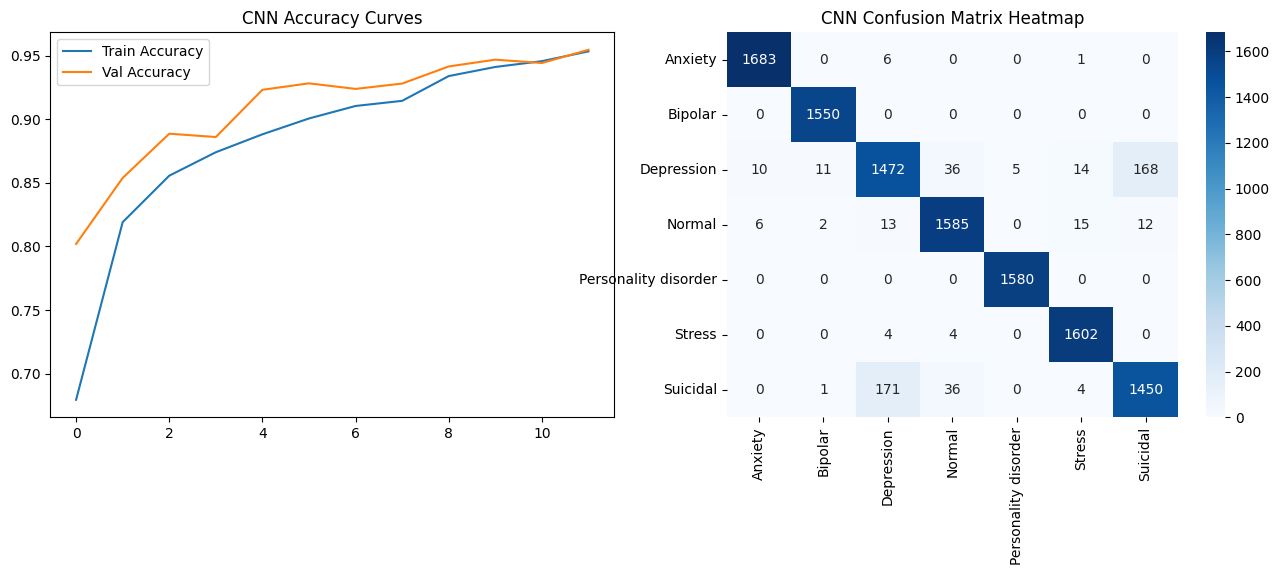

In [9]:
plt.figure(figsize=(16, 5))

# Plot Accuracy & Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy Curves')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('CNN Confusion Matrix Heatmap')
plt.show()

In [10]:
def analyze_mental_health(text):
    """
    Function to preprocess text, predict mental health status using CNN,
    and calculate intensity.
    """
    clean_text = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean_text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    
    prediction = model.predict(padded, verbose=0)[0]
    class_idx = np.argmax(prediction)
    emotion = label_encoder.classes_[class_idx]
    confidence = prediction[class_idx]
    
    # Intensity Logic
    if confidence > 0.80:
        intensity = "High / Acute"
    elif confidence > 0.50:
        intensity = "Moderate"
    else:
        intensity = "Low / Emerging"
        
    print(f"\n--- Mental Health Analysis (CNN) ---")
    print(f"Post: {text}")
    print(f"Detected: {emotion}")
    print(f"Intensity: {intensity} ({confidence*100:.1f}%)")
    print("-" * 40)

# --- DIRECT INPUT TEST CASES ---
print("[RUNNING DIRECT TEST CASES]")

# Static Test Cases
analyze_mental_health("I can't stop my hands from shaking and I feel like something terrible is about to happen.")
analyze_mental_health("I have so much work to do and I feel completely overwhelmed by the deadlines.")
analyze_mental_health("I don't see the point in anything anymore, I've lost all hope for the future.")

print("\nCNN Project Analysis Complete.")

[RUNNING DIRECT TEST CASES]

--- Mental Health Analysis (CNN) ---
Post: I can't stop my hands from shaking and I feel like something terrible is about to happen.
Detected: Normal
Intensity: Low / Emerging (39.7%)
----------------------------------------

--- Mental Health Analysis (CNN) ---
Post: I have so much work to do and I feel completely overwhelmed by the deadlines.
Detected: Depression
Intensity: Moderate (60.5%)
----------------------------------------

--- Mental Health Analysis (CNN) ---
Post: I don't see the point in anything anymore, I've lost all hope for the future.
Detected: Suicidal
Intensity: Low / Emerging (42.7%)
----------------------------------------

CNN Project Analysis Complete.
